<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- REINFORCEMENT LEARNING --

## Q1 - Install dependencies

In [1]:
!pip install --quiet swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.6 MB/s eta 0:00:00


In [2]:
!pip install --quiet gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 28.4 MB/s eta 0:00:00


In [3]:
!pip install --quiet renderlab

In [4]:
!pip install --quiet rllib

In [5]:
!pip install --quiet stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 2.6 MB/s eta 0:00:00


## Q2 - `step`, `reset` and `render` explanation
* `step`: for a given environment state, this function takes into account the agent's action and produces the next state, after also producing the reward accordingly
* `reset`: this function resets the environment state to an initial internal state, generating a new random starting state
* `render`: this function returns an array which can be rendered to the screen as pixels, or it can be fed to a Neural Network to train an RL agent

## Q3 - Describing the `LunarLander` environment
1) Observation space: The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.
2) Action space: There are four discrete actions available:
    0) do nothing
    1) fire left orientation engine
    2) fire main engine
    3) fire right orientation engine
3) Reward function: After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.
For each step, the reward:
    * is increased/decreased the closer/further the lander is to the landing pad.
    * is increased/decreased the slower/faster the lander is moving.
    * is decreased the more the lander is tilted (angle not horizontal).
    * is increased by 10 points for each leg that is in contact with the ground.
    * is decreased by 0.03 points each frame a side engine is firing.
    * is decreased by 0.3 points each frame the main engine is firing.

    The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.\
    An episode is considered a solution if it scores at least 200 points.

## Q4 - Create an RL agent and visualize its progress

### Import libraries

In [73]:
import renderlab as rl
import gymnasium as gym
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
import numpy as np

In [84]:

env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, "./output")

observation, info = env.reset()

while True:
  action = env.action_space.sample()
  observation, reward, terminated, truncated, info = env.step(action)

  if terminated or truncated:
    break

env.play()

## Q5 - Average score after 5 random episodes

In [16]:
env = gym.make("LunarLander-v3") #, render_mode="rgb_array")
observation, info = env.reset()

count = 0
total_reward = 0
while count < 5:
  action = env.action_space.sample()
  observation, reward, terminated, truncated, info = env.step(action)
  total_reward += reward
  done = terminated or truncated
  if done:
    count += 1

total_reward /= count # get average
print(f"Average reward of a random agent: {total_reward}")

Average reward of a random agent: -149.57329770804563


## Q6 - Train an agent using StableBaselines

### a) Deep Q Network (DQN)

In [24]:
# CLEAN LIVE DISPLAY
# link: https://github.com/DLR-RM/stable-baselines3/issues/1645
import gc

# On cherche tous les objets dont le nom du type contient tqdm
tqdm_objects = [obj for obj in gc.get_objects() if 'tqdm' in type(obj).__name__]

for tqdm_object in tqdm_objects:
    print(type(tqdm_object).__name__)

for tqdm_object in tqdm_objects:
    if 'tqdm_rich' in type(tqdm_object).__name__:
        tqdm_object.close()

tqdm_rich
tqdm_rich


AttributeError: 'tqdm_rich' object has no attribute '_task_id'

In [71]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

model = DQN("MlpPolicy", env)#, verbose=0)
model.learn(total_timesteps=int(2e5), progress_bar=True)

model.save("dqn_lunar")

mean_reward, std_reward = evaluate_policy(model, model.get_env(),
                                          n_eval_episodes=10)

print(f"Mean score: {mean_reward}, std: {std_reward}")

  self.pbar = tqdm(total=self.locals["total_timesteps"] - self.model.num_timesteps)



Output()

Mean score: -63.9444993, std: 86.78110698405334


In [66]:
import gymnasium as gym
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

# Create env with rgb_array rendering
env = gym.make("LunarLander-v3", render_mode="rgb_array")

# model = DQN.load("dqn_lunar", env=env)

frames = []

obs, info = env.reset()
while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    frames.append(frame)

    if terminated or truncated:
        obs, info = env.reset()
        break

env.close()


In [68]:
from matplotlib import animation
from IPython.display import HTML
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(5,5))
plt.axis("off")
img = plt.imshow(frames[0])

def animate(i):
    img.set_data(frames[i])
    return [img]

anim = animation.FuncAnimation(
    fig, animate, frames=len(frames), interval=30
)
anim.save("ppo_lunar.gif")
HTML(anim.to_jshtml())

### b) Proximal Policy Optimization (PPO)

In [60]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

model = PPO("MlpPolicy", env)#, verbose=0)
model.learn(total_timesteps=int(2e5), progress_bar=True)

model.save("ppo_lunar")

mean_reward_ppo, std_reward_ppo = evaluate_policy(model, model.get_env(),
                                          n_eval_episodes=10)

print(f"Mean score: {mean_reward_ppo}, std: {std_reward_ppo}")

Output()

Mean score: -90.4360257, std: 34.33326158801692


## Q7 - Average score after training + metrics

Text(0.5, 1.0, 'Average Reward per Environment Step (Mean ± Std)')

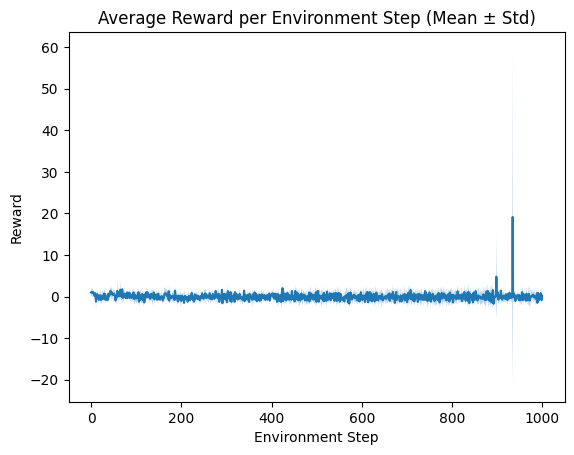

In [82]:
env = gym.make("LunarLander-v3")
obs, _ = env.reset()
model = DQN.load("dqn_lunar.zip")
num_episodes = 5
rewards = []

for _ in range(num_episodes):
    done = False
    episode_rewards = []

    while not done:
        action, _ = model.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        episode_rewards.append(reward)
        done = terminated or truncated

    rewards.append(episode_rewards)
    obs, _ = env.reset()

env.close()

# pad episodes to same length
max_len = max(len(r) for r in rewards)
padded = np.full((num_episodes, max_len), np.nan)

for i, r in enumerate(rewards):
    padded[i, :len(r)] = r

mean_rewards = np.nanmean(padded, axis=0)
std_rewards = np.nanstd(padded, axis=0)

plt.plot(mean_rewards)
plt.fill_between(
    range(len(mean_rewards)),
    mean_rewards - std_rewards,
    mean_rewards + std_rewards, alpha=.3
)
plt.xlabel("Environment Step")
plt.ylabel("Reward")
plt.title("DQN - Average Reward per Environment Step (Mean ± Std)")

Text(0.5, 1.0, 'PPO - Average Reward per Environment Step (Mean ± Std)')

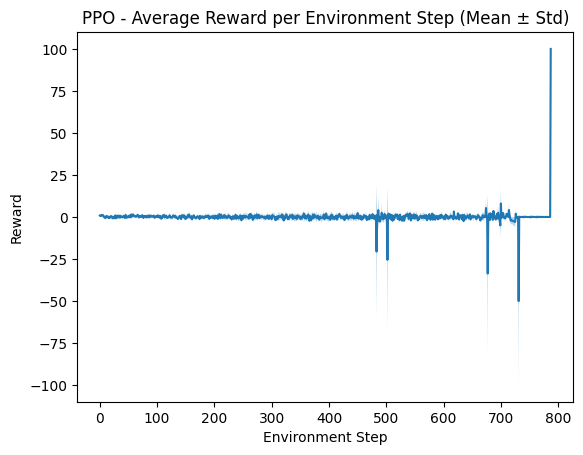

In [84]:
env = gym.make("LunarLander-v3")
obs, _ = env.reset()
model = PPO.load("ppo_lunar.zip")
num_episodes = 5
rewards = []

for _ in range(num_episodes):
    done = False
    episode_rewards = []

    while not done:
        action, _ = model.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        episode_rewards.append(reward)
        done = terminated or truncated

    rewards.append(episode_rewards)
    obs, _ = env.reset()

env.close()

# pad episodes to same length
max_len = max(len(r) for r in rewards)
padded = np.full((num_episodes, max_len), np.nan)

for i, r in enumerate(rewards):
    padded[i, :len(r)] = r

mean_rewards = np.nanmean(padded, axis=0)
std_rewards = np.nanstd(padded, axis=0)

plt.plot(mean_rewards)
plt.fill_between(
    range(len(mean_rewards)),
    mean_rewards - std_rewards,
    mean_rewards + std_rewards, alpha=.3
)
plt.xlabel("Environment Step")
plt.ylabel("Reward")
plt.title("PPO - Average Reward per Environment Step (Mean ± Std)")

### Training time
Training time is comparable between the DQN and PPO approaches, ~10 minutes using a CPU for 200 thousand epochs.

## Q8 - Optimize the Lunar Landing agent